<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B06%5D%20-%20Deep%20Learning/07_CNN_Basico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# CNN básica — Fashion-MNIST (end‑to‑end)

Este notebook entrena una **CNN (Red Neuronal Convolucional)** sobre **Fashion‑MNIST** usando TensorFlow/Keras.

- Dataset **online y fijo** (se descarga automáticamente la primera vez, igual que en el notebook de MLP).
- Código **paso a paso**, sencillo y con buenas prácticas mínimas.
- Incluye **EarlyStopping**, **conjunto de validación estratificado**, **curvas de entrenamiento** y **predicciones de ejemplo**.
- **Compara directamente** los resultados con el MLP anterior: verás por qué la CNN rinde mejor en imágenes.

---

### ¿Por qué CNN en lugar de MLP?

En el notebook anterior (MLP), aplanamos la imagen 28×28 a un vector de 784 valores. Eso **destruye la información espacial**: el modelo ya no sabe qué píxeles están juntos.

Una CNN, en cambio, trabaja directamente sobre la cuadrícula 2D de la imagen usando **filtros convolucionales** que aprenden a detectar patrones locales (bordes, texturas, formas) y son **invariantes a la traslación** (detectan el patrón donde sea que aparezca en la imagen).

| | MLP | CNN |
|---|---|---|
| Input | Vector plano (784,) | Imagen 2D (28×28×1) |
| Detecta patrones locales | ❌ | ✅ |
| Invariante a traslación | ❌ | ✅ |
| Parámetros 1ª capa | 100.480 | ~320 |
| Accuracy esperado | ~88-90% | ~92-94% |

> Si te faltan dependencias: `pip install tensorflow scikit-learn matplotlib`


In [1]:
# (Opcional) Instalar dependencias si faltan — ejecuta manualmente si es necesario
!pip install tensorflow scikit-learn matplotlib

In [2]:
# 1) Importaciones
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [3]:
# 2) Reproducibilidad
def set_global_seed(seed: int = 42):
    """Fija semillas para intentar resultados reproducibles."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        tf.config.experimental.enable_op_determinism(True)
    except Exception:
        pass
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed(42)
print("Semilla global fijada en 42.")

Semilla global fijada en 42.


In [4]:
# 2.1) Ver datos de origen y jugar con ellos
from tensorflow.keras.datasets import fashion_mnist

# Carga sin tocar los datos
(X_train_full_2, y_train_full_2), _ = fashion_mnist.load_data()

# La primera imagen "raw"
img = X_train_full_2[0]  # matriz 28x28 de enteros uint8 (0..255)

print("Shape:", img.shape)
print("dtype:", img.dtype)
print("valor mínimo / máximo:", img.min(), "/", img.max())

# Imprime la matriz completa tal cual
np.set_printoptions(linewidth=120, threshold=np.inf)
print("Matriz de píxeles (0..255):")
print(img)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape: (28, 28)
dtype: uint8
valor mínimo / máximo: 0 / 255
Matriz de píxeles (0..255):
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0   0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62  54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134 144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0 

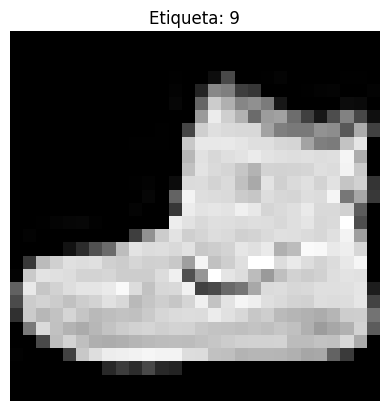

In [5]:
# Renderizamos la imagen en escala de grises
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title(f"Etiqueta: {y_train_full_2[0]}")
plt.axis("off")
plt.show()

# DIFERENCIA CLAVE vs MLP:
# En el MLP aplanábamos esta imagen a un vector de 784 valores.
# En la CNN vamos a mantener la estructura 2D (28x28). El modelo necesita
# ver los píxeles como una cuadrícula para detectar patrones espaciales.

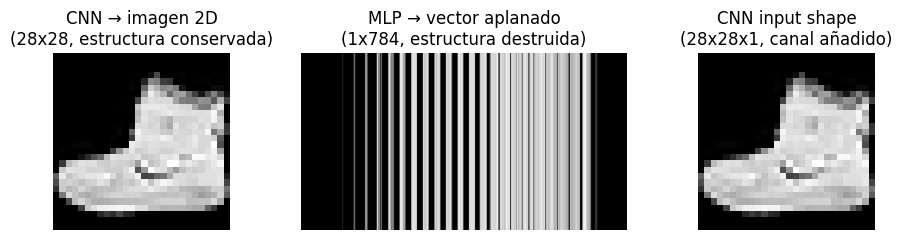

In [6]:
# --- Comparación visual: cómo ve el dato cada arquitectura ---
plt.figure(figsize=(10, 2.5))

# Tal como lo ve la CNN: imagen 2D intacta
plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("CNN → imagen 2D\n(28x28, estructura conservada)")
plt.axis("off")

# Tal como lo vería el MLP: vector aplanado
plt.subplot(1, 3, 2)
plt.imshow(img.reshape(1, -1), cmap="gray", aspect="auto")
plt.title("MLP → vector aplanado\n(1x784, estructura destruida)")
plt.axis("off")

# Canal de color añadido para CNN (28x28x1)
plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.title("CNN input shape\n(28x28x1, canal añadido)")
plt.axis("off")

plt.tight_layout()
plt.show()

# El canal de color '1' indica escala de grises. Una imagen RGB tendría 3 canales.
# Keras/TensorFlow espera el formato (alto, ancho, canales) → (28, 28, 1)

In [7]:
# 3) Carga y preparación de datos (Fashion-MNIST)
from tensorflow.keras.datasets import fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Normalizar a [0,1]
X_train_full = X_train_full.astype("float32") / 255.0
X_test       = X_test.astype("float32")       / 255.0

# DIFERENCIA CLAVE vs MLP:
# En el MLP hacíamos: reshape((N, -1))      → vector (N, 784)       [aplanar]
# En la CNN hacemos:  reshape((N, 28, 28, 1)) → imagen 3D (N, alto, ancho, canales)
# El canal '1' indica escala de grises. RGB tendría 3 canales.
X_train_full = X_train_full.reshape((-1, 28, 28, 1))
X_test       = X_test.reshape((-1, 28, 28, 1))

# Split estratificado: mantiene las proporciones de clase (igual que en MLP)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

num_classes = 10
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("Tamaño train:", X_train.shape, "\tTamaño val:", X_val.shape, "\tTamaño test:", X_test.shape)
print()
print("Shape de UNA imagen para la CNN:", X_train[0].shape)
print("  → (alto=28, ancho=28, canales=1)  —  la estructura 2D está CONSERVADA")

Tamaño train: (48000, 28, 28, 1) 	Tamaño val: (12000, 28, 28, 1) 	Tamaño test: (10000, 28, 28, 1)

Shape de UNA imagen para la CNN: (28, 28, 1)
  → (alto=28, ancho=28, canales=1)  —  la estructura 2D está CONSERVADA


In [8]:
# 4) Construcción de la CNN

# ¿Qué es una capa Conv2D?
# Un conjunto de filtros (pequeñas matrices, p.ej. 3x3) que se deslizan por la imagen.
# Cada filtro aprende a detectar un patrón: bordes verticales, curvas, texturas...
# El resultado se llama 'mapa de activación' o 'feature map'.
#
# ¿Qué es MaxPooling2D?
# Reduce el tamaño espacial (ancho y alto) a la mitad, quedándose con el valor
# máximo de cada región 2x2. Ventajas: menos parámetros, cierta invarianza a traslación.
#
# ¿Qué es Flatten?
# Convierte el volumen 3D (feature maps) en un vector 1D para poder conectarlo
# a las capas Dense finales (igual que en el MLP). Aquí sí aplanamos, pero
# DESPUÉS de que los filtros han extraído las características relevantes.

def build_cnn(num_classes: int = 10) -> keras.Model:
    model = keras.Sequential([
        # --- BLOQUE 1: primer extractor de características ---
        layers.Input(shape=(28, 28, 1)),           # Entrada: imagen 28x28 en escala de grises (1 canal)

        layers.Conv2D(32, kernel_size=(3, 3),      # 32 filtros de 3x3 píxeles
                      activation="relu",           # ReLU: activa solo si detecta el patrón
                      padding="same"),             # 'same' conserva el tamaño espacial (28x28)
        layers.MaxPooling2D(pool_size=(2, 2)),      # Reduce de 28x28 → 14x14

        # --- BLOQUE 2: segundo extractor, patrones más complejos ---
        layers.Conv2D(64, kernel_size=(3, 3),      # 64 filtros: captura patrones más abstractos
                      activation="relu",
                      padding="same"),             # Tamaño conservado: 14x14
        layers.MaxPooling2D(pool_size=(2, 2)),      # Reduce de 14x14 → 7x7

        layers.Dropout(0.25),                      # Regularización: apaga 25% de activaciones al azar
                                                   # Reduce overfitting en los feature maps

        # --- TRANSICIÓN: de volumen 3D a vector 1D ---
        layers.Flatten(),                          # (7x7x64) = 3.136 valores → vector
                                                   # A diferencia del MLP (784), aquí aplanamos
                                                   # CARACTERÍSTICAS, no píxeles crudos

        # --- CLASIFICADOR FINAL (igual que el MLP, pero sobre features extraídas) ---
        layers.Dense(128, activation="relu"),      # Capa densa: combina las características extraídas
        layers.Dropout(0.5),                       # Dropout más agresivo antes de la salida (50%)
        layers.Dense(num_classes, activation="softmax")  # 10 salidas → probabilidades de cada clase
    ])
    return model

model = build_cnn(num_classes=num_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

### Análisis del `model.summary()`

**Bloque 1 — Conv2D(32, 3×3):**
```
Output shape: (None, 28, 28, 32)
Parámetros = (3×3×1 + 1 bias) × 32 filtros = 320
```
Compara con la primera capa del MLP: `Dense(128)` tenía **100.480 parámetros**.
La CNN aprende con **~300× menos parámetros** en la primera capa y aun así lo hace mejor.
¿Por qué? Porque el filtro se reutiliza en cada posición de la imagen (**peso compartido**).

**Bloque 2 — Conv2D(64, 3×3):**
```
Output shape: (None, 14, 14, 64)
Parámetros = (3×3×32 + 1 bias) × 64 filtros = 18.496
```
El segundo bloque ve los feature maps del primero y aprende combinaciones más complejas (partes de prendas, siluetas).

**Flatten:**
```
7 × 7 × 64 = 3.136  →  vector de CARACTERÍSTICAS (no de píxeles crudos como en el MLP)
```
El Dense final clasifica sobre esas características aprendidas, no sobre píxeles directamente.

In [9]:
# 5) Entrenamiento con EarlyStopping (mismos hiperparámetros que el MLP para comparar justo)
model.compile(
    optimizer="adam",                            # Adam con lr por defecto (1e-3)
    loss="sparse_categorical_crossentropy",      # Pérdida para clasificación multiclase con etiquetas enteras
    metrics=["accuracy"]                         # Métrica que monitorizamos
)

# Early Stopping: para el entrenamiento si val_loss no mejora 3 épocas seguidas
# y restaura los mejores pesos (igual que en MLP)
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,           # Mismo número de épocas máximas que el MLP
    batch_size=128,      # Mismo batch size que el MLP
    callbacks=[early_stop],
    verbose=1
)
print("Entrenamiento finalizado.")

# NOTA sobre velocidad:
# La CNN es más lenta por época que el MLP (más operaciones por imagen),
# pero suele necesitar menos épocas para converger y llega a un accuracy mayor.

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 94ms/step - accuracy: 0.7794 - loss: 0.6139 - val_accuracy: 0.8711 - val_loss: 0.3561
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 94ms/step - accuracy: 0.8595 - loss: 0.3896 - val_accuracy: 0.8923 - val_loss: 0.2996
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 93ms/step - accuracy: 0.8772 - loss: 0.3418 - val_accuracy: 0.9003 - val_loss: 0.2800
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.8879 - loss: 0.3114 - val_accuracy: 0.9058 - val_loss: 0.2563
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.8969 - loss: 0.2831 - val_accuracy: 0.9133 - val_loss: 0.2402
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.9009 - loss: 0.2710 - val_accuracy: 0.9160 - val_loss: 0.2303
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 91ms/step - accuracy: 0.9067 - loss: 0.2557 - val_accuracy: 0.9178 - val_loss: 0.2270
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 91ms/step - accuracy: 0.9111 - loss: 0.2413 - 

### Lectura del log de entrenamiento

```
375/375 — loss: 0.5312 — accuracy: 0.8071 — val_loss: 0.3521 — val_accuracy: 0.8734
```

- `375/375`: batches procesados en train esta época.
- `accuracy`: exactitud en **train**. Al empezar es más baja porque el modelo aún aprende.
- `val_accuracy`: exactitud en **validación** (datos no vistos durante el entrenamiento).
- `val_loss`: la métrica que vigila el EarlyStopping. Si no baja 3 épocas seguidas → para y restaura los mejores pesos.

Es normal que al principio `val_accuracy > train_accuracy`: el Dropout está activo solo en train (apaga neuronas), mientras que en validación todas las neuronas funcionan.

Loss (test):     0.2379
Accuracy (test): 0.9166

→ Compara con el MLP: ~0.88. La CNN debería dar ~0.92-0.94

Reporte de clasificación:
              precision    recall  f1-score   support

 T-shirt/top     0.8852    0.8560    0.8704      1000
     Trouser     0.9959    0.9810    0.9884      1000
    Pullover     0.8944    0.8470    0.8701      1000
       Dress     0.9114    0.9160    0.9137      1000
        Coat     0.8378    0.9040    0.8696      1000
      Sandal     0.9840    0.9850    0.9845      1000
       Shirt     0.7422    0.7600    0.7510      1000
     Sneaker     0.9603    0.9680    0.9641      1000
         Bag     0.9909    0.9780    0.9844      1000
  Ankle boot     0.9739    0.9710    0.9725      1000

    accuracy                         0.9166     10000
   macro avg     0.9176    0.9166    0.9169     10000
weighted avg     0.9176    0.9166    0.9169     10000



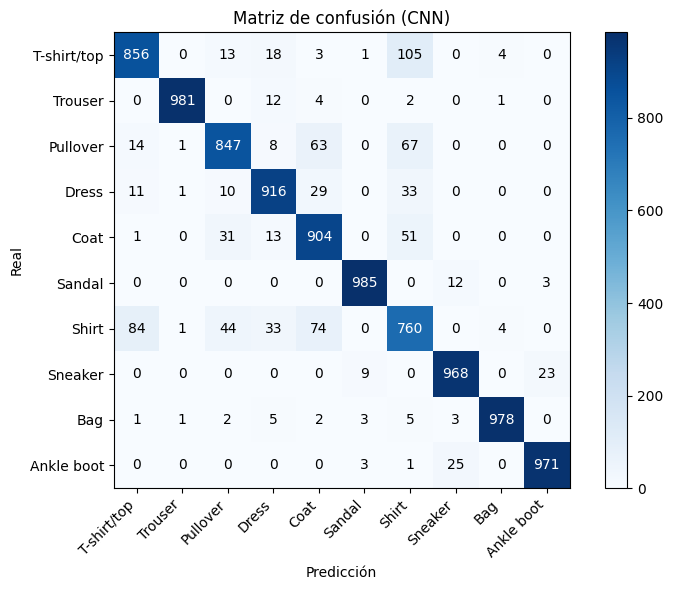

In [10]:
# 6) Evaluación en test + reporte (mismo código que en MLP para comparar directamente)
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss (test):     {loss:.4f}")
print(f"Accuracy (test): {acc:.4f}")
print()
print("→ Compara con el MLP: ~0.88. La CNN debería dar ~0.92-0.94")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de confusión (CNN)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar()
plt.tight_layout()
plt.show()

# Clases con más confusión habitual en Fashion-MNIST:
# Shirt vs T-shirt/top vs Pullover → formas similares, difíciles incluso para humanos
# Sneaker vs Ankle boot → siluetas parecidas

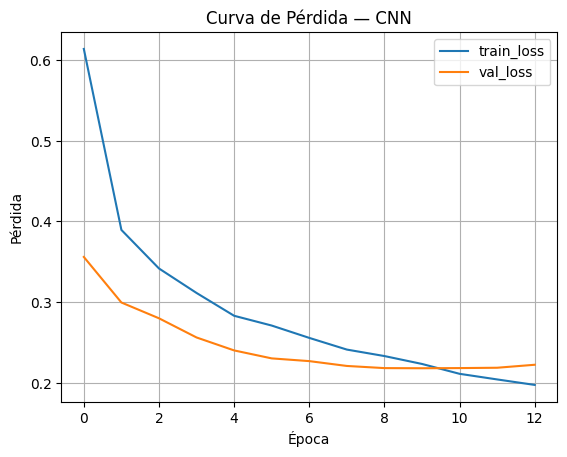

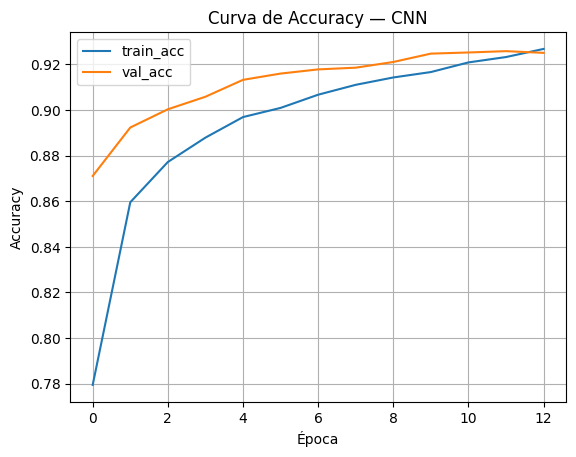

In [11]:
# 7) Curvas de aprendizaje — pérdida y accuracy (mismo formato que en MLP)
hist = history.history

# Curva de pérdida — cuanto más baja, mejor
plt.figure()
plt.plot(hist["loss"],     label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Curva de Pérdida — CNN")
plt.legend()
plt.grid(True)
plt.show()

# Curva de accuracy — cuanto más alto, mejor
plt.figure()
plt.plot(hist["accuracy"],     label="train_acc")
plt.plot(hist["val_accuracy"], label="val_acc")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Curva de Accuracy — CNN")
plt.legend()
plt.grid(True)
plt.show()

### Interpretación de las curvas

**Curva de pérdida:**
- Ambas curvas (train y val) deben bajar juntas al principio. ✅
- Si `val_loss` sube mientras `train_loss` baja → **overfitting** → más Dropout, menos filtros, o EarlyStopping más agresivo.
- Si ambas se estancan pronto → **underfitting** → más filtros, más bloques convolucionales o más épocas.

**Curva de accuracy:**
- Cuanto más alta, mejor.
- Con Dropout activo en train, es normal que `val_accuracy` supere `train_accuracy` en las primeras épocas.

**Consejos rápidos:**

| Síntoma | Solución |
|---|---|
| Gap grande (train >> val) | Más Dropout, menos filtros, EarlyStopping |
| Ambas malas | Más filtros, más bloques Conv, más épocas |
| Oscila mucho | Reduce LR, batch más grande o clipping de gradiente |
| Se estanca pronto | Sube LR o usa ReduceLROnPlateau |

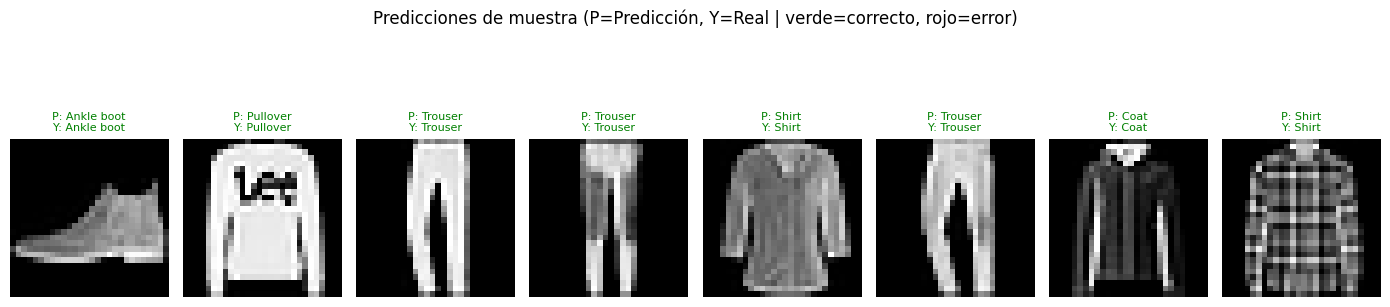

In [12]:
# 8) Predicciones de muestra — mismas imágenes que en MLP para comparar directamente
num_samples = 8
idx         = np.arange(0, num_samples)
X_subset    = X_test[idx]   # shape: (8, 28, 28, 1)
y_subset    = y_test[idx]

y_probs = model.predict(X_subset, verbose=0)
y_pred  = np.argmax(y_probs, axis=1)

# .squeeze() elimina el canal: (28,28,1) → (28,28) para visualizar con imshow
images = X_subset.squeeze()

plt.figure(figsize=(14, 4))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(images[i], cmap="gray")
    # Verde si acierta, rojo si falla
    color = "green" if y_pred[i] == y_subset[i] else "red"
    title = f"P: {class_names[y_pred[i]]}\nY: {class_names[y_subset[i]]}"
    plt.title(title, fontsize=8, color=color)
    plt.axis("off")
plt.suptitle("Predicciones de muestra (P=Predicción, Y=Real | verde=correcto, rojo=error)")
plt.tight_layout()
plt.show()

## Comparativa final: MLP vs CNN

| Métrica | MLP | CNN |
|---|---|---|
| Accuracy (test) | ~88-90% | ~92-94% |
| Input del modelo | Vector (784,) | Imagen (28, 28, 1) |
| Información espacial | ❌ Destruida al aplanar | ✅ Conservada |
| Invarianza a traslación | ❌ | ✅ |
| Parámetros capa 1 | 100.480 | 320 |
| Detecta bordes y texturas | Implícitamente (si tiene suerte) | ✅ Explícitamente con filtros |

### ¿Cuándo usar cada arquitectura?

- **MLP**: datos tabulares, señales 1D simples, cuando **no existe estructura espacial**.
- **CNN**: imágenes, vídeo, espectrogramas de audio, cualquier dato con estructura local o espacial.

### ¿Y si quiero más accuracy todavía?

- **Transfer Learning**: usar una CNN pre-entrenada (ResNet, EfficientNet, MobileNet) como extractor de características y fine-tunear solo las últimas capas. Con Fashion-MNIST puede llegar al **95-96%** sin esfuerzo.
- **Data Augmentation**: rotaciones, flips, zoom aleatorio durante el entrenamiento → modelo más robusto y menos overfitting.